<a href="https://colab.research.google.com/github/DalpesCS50/trab_estagio4_health-insurance-claims-prediction/blob/main/notebooks/01_exploracao_inicial_health_insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predição do Valor de Sinistros em Seguro Saúde

## Estágio Supervisionado IV - Matemática Atuarial III

### Exploração inicial do conjunto de dados Health Insurance

**Objetivo:** realizar a exploração inicial do conjunto de dados *Health Insurance Data Set*, identificando sua estrutura, suas variáveis e as principais características dos dados que serão utilizados no desenvolvimento de um modelo preditivo para estimar o valor dos sinistros em seguro saúde.

## 1. Definição do problema

O custo dos sinistros é uma variável fundamental para a gestão de uma carteira de seguros, pois influencia diretamente a precificação, o planejamento financeiro e a avaliação dos riscos assumidos pela seguradora.

Neste projeto, pretende-se investigar se as características observadas dos segurados podem ser utilizadas para prever o valor dos sinistros em seguro saúde.

### Pergunta preditiva

**É possível estimar o valor do sinistro de um segurado a partir de suas características demográficas e de seus fatores de risco relacionados à saúde?**

### Variável resposta

A variável que se pretende prever é **`claim`**, que representa o valor do sinistro reclamado pelo segurado.

### Variáveis preditoras

As demais características disponíveis no conjunto de dados serão inicialmente consideradas como potenciais variáveis explicativas do valor dos sinistros. A relevância de cada uma delas será investigada posteriormente durante a análise exploratória e a modelagem.

In [2]:
import pandas as pd

In [3]:
url = "https://raw.githubusercontent.com/DalpesCS50/trab_estagio4_health-insurance-claims-prediction/refs/heads/main/data/healthinsurance.csv"

dados = pd.read_csv(url)

In [4]:
dados.head()

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72,0,0,Actor,13112.6
1,49.0,female,75,22.6,NoDisease,1,0,Boston,78,1,1,Engineer,9567.0
2,32.0,female,64,17.8,Epilepsy,2,1,Phildelphia,88,1,1,Academician,32734.2
3,61.0,female,53,36.4,NoDisease,1,1,Pittsburg,72,1,0,Chef,48517.6
4,19.0,female,50,20.6,NoDisease,0,0,Buffalo,82,1,0,HomeMakers,1731.7


In [5]:
dados.shape

(15000, 13)

In [6]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  14604 non-null  float64
 1   sex                  15000 non-null  object 
 2   weight               15000 non-null  int64  
 3   bmi                  14044 non-null  float64
 4   hereditary_diseases  15000 non-null  object 
 5   no_of_dependents     15000 non-null  int64  
 6   smoker               15000 non-null  int64  
 7   city                 15000 non-null  object 
 8   bloodpressure        15000 non-null  int64  
 9   diabetes             15000 non-null  int64  
 10  regular_ex           15000 non-null  int64  
 11  job_title            15000 non-null  object 
 12  claim                15000 non-null  float64
dtypes: float64(3), int64(6), object(4)
memory usage: 1.5+ MB


In [7]:
dados.isnull().sum()

,0
age,396
sex,0
weight,0
bmi,956
hereditary_diseases,0
no_of_dependents,0
smoker,0
city,0
bloodpressure,0
diabetes,0


In [8]:
(dados.isnull().sum() / len(dados)) * 100

,0
age,2.640000
sex,0.000000
weight,0.000000
bmi,6.373333
hereditary_diseases,0.000000
no_of_dependents,0.000000
smoker,0.000000
city,0.000000
bloodpressure,0.000000
diabetes,0.000000


In [9]:
dados.isnull().any(axis=1).sum()

np.int64(1352)

In [10]:
dados[dados["age"].isnull() & dados["bmi"].isnull()].shape

(0, 13)

In [11]:
dados.duplicated().sum()

np.int64(1096)

In [12]:
dados[dados.duplicated(keep=False)].sort_values(
    by=list(dados.columns)
).head(20)

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
2005,18.0,female,40,24.8,NoDisease,0,0,Charleston,60,0,0,HouseKeeper,2203.7
2362,18.0,female,40,24.8,NoDisease,0,0,Charleston,60,0,0,HouseKeeper,2203.7
4078,18.0,female,44,26.3,NoDisease,0,0,Fargo,76,1,0,Labourer,2198.2
8072,18.0,female,44,26.3,NoDisease,0,0,Fargo,76,1,0,Labourer,2198.2
833,18.0,female,44,NaN,NoDisease,0,0,Charleston,96,1,0,Photographer,21344.9
6897,18.0,female,44,NaN,NoDisease,0,0,Charleston,96,1,0,Photographer,21344.9
1377,18.0,female,46,29.2,NoDisease,0,0,SantaRosa,64,1,1,FashionDesigner,7323.7
10350,18.0,female,46,29.2,NoDisease,0,0,SantaRosa,64,1,1,FashionDesigner,7323.7
9571,18.0,female,48,20.3,NoDisease,0,0,Nashville,60,1,0,HomeMakers,11482.6
12142,18.0,female,48,20.3,NoDisease,0,0,Nashville,60,1,0,HomeMakers,11482.6


In [13]:
dados.drop_duplicates().shape

(13904, 13)

### 1.1 Verificação inicial da qualidade dos dados

O conjunto de dados original possui **15.000 observações e 13 variáveis**.

A análise de valores ausentes identificou:

- **396 valores ausentes em `age`**, correspondentes a **2,64%** das observações;
- **956 valores ausentes em `bmi`**, correspondentes a aproximadamente **6,37%** das observações;
- não foram identificados valores ausentes nas demais variáveis;
- não existem registros em que `age` e `bmi` estejam simultaneamente ausentes.

No total, **1.352 observações apresentam pelo menos um valor ausente**, enquanto **13.648 observações estão completas em todas as variáveis**.

Também foram identificadas **1.096 linhas duplicadas** considerando conjuntamente as 13 variáveis do conjunto de dados. Caso as duplicidades sejam removidas, a base passa de 15.000 para **13.904 registros únicos**.

Nesta etapa exploratória, os valores ausentes e os registros duplicados foram apenas identificados. As decisões relativas ao tratamento dessas ocorrências serão realizadas posteriormente, durante a etapa de preparação dos dados para a modelagem.

In [14]:
dados.nunique()

,0
age,47
sex,2
weight,58
bmi,269
hereditary_diseases,10
no_of_dependents,6
smoker,2
city,91
bloodpressure,69
diabetes,2


In [15]:
print("sex:", dados["sex"].unique())
print("smoker:", dados["smoker"].unique())
print("diabetes:", dados["diabetes"].unique())
print("regular_ex:", dados["regular_ex"].unique())

sex: ['male' 'female']
smoker: [0 1]
diabetes: [0 1]
regular_ex: [0 1]


In [16]:
dados["hereditary_diseases"].unique()

array(['NoDisease', 'Epilepsy', 'EyeDisease', 'Alzheimer', 'Arthritis',
       'HeartDisease', 'Diabetes', 'Cancer', 'High BP', 'Obesity'],
      dtype=object)

In [17]:
dados["hereditary_diseases"].value_counts()

,count
hereditary_diseases,
NoDisease,13998
Diabetes,148
Alzheimer,144
Obesity,136
EyeDisease,123
Cancer,109
Arthritis,96
HeartDisease,93
Epilepsy,84


In [18]:
dados["diabetes"].value_counts()

,count
diabetes,
1,11655
0,3345


In [19]:
pd.crosstab(dados["hereditary_diseases"], dados["diabetes"])

diabetes,0,1
hereditary_diseases,,
Alzheimer,4,140
Arthritis,15,81
Cancer,6,103
Diabetes,6,142
Epilepsy,18,66
EyeDisease,19,104
HeartDisease,0,93
High BP,5,64
NoDisease,3248,10750


In [20]:
for variavel in ["smoker", "diabetes", "regular_ex"]:
    print(f"\n{variavel}")
    print(dados[variavel].value_counts())


smoker
smoker
0    12028
1     2972
Name: count, dtype: int64

diabetes
diabetes
1    11655
0     3345
Name: count, dtype: int64

regular_ex
regular_ex
0    11638
1     3362
Name: count, dtype: int64


In [21]:
dados["sex"].value_counts()

,count
sex,
female,7652
male,7348


In [22]:
dados["sex"].value_counts(normalize=True) * 100

,proportion
sex,
female,51.013333
male,48.986667


In [23]:
dados["city"].value_counts().head(10)

,count
city,
Nashville,302
NewOrleans,302
Charleston,298
Brimingham,298
Memphis,297
Charlotte,293
Louisville,293
Newport,280
Stamford,280


In [24]:
dados["city"].value_counts().tail(10)

,count
city,
SanFrancisco,103
Eureka,103
Huntsville,96
Macon,96
Orlando,96
Warwick,69
Syracuse,69
Trenton,69
York,69


In [25]:
sorted(dados["city"].unique())

['Atlanta',
 'AtlanticCity',
 'Bakersfield',
 'Baltimore',
 'Bloomington',
 'Boston',
 'Brimingham',
 'Brookings',
 'Buffalo',
 'Cambridge',
 'Canton',
 'Carlsbad',
 'Charleston',
 'Charlotte',
 'Chicago',
 'Cincinnati',
 'Cleveland',
 'Columbia',
 'Columbus',
 'Denver',
 'Escabana',
 'Eureka',
 'FallsCity',
 'Fargo',
 'Florence',
 'Fresno',
 'Georgia',
 'GrandForks',
 'Harrisburg',
 'Hartford',
 'Houston',
 'Huntsville',
 'Indianapolis',
 'IowaCity',
 'JeffersonCity',
 'KanasCity',
 'Kingman',
 'Kingsport',
 'Knoxville',
 'LasVegas',
 'Lincoln',
 'LosAngeles',
 'Louisville',
 'Lovelock',
 'Macon',
 'Mandan',
 'Marshall',
 'Memphis',
 'Mexicali',
 'Miami',
 'Minneapolis',
 'Minot',
 'Montrose',
 'Nashville',
 'NewOrleans',
 'NewYork',
 'Newport',
 'Oceanside',
 'Oklahoma',
 'Orlando',
 'Oxnard',
 'PanamaCity',
 'Pheonix',
 'Phildelphia',
 'Pittsburg',
 'Portland',
 'Prescott',
 'Providence',
 'Raleigh',
 'Reno',
 'Rochester',
 'Salina',
 'SanDeigo',
 'SanFrancisco',
 'SanJose',
 'SanLu

In [26]:
dados["job_title"].value_counts()

,count
job_title,
Student,1320
HomeMakers,972
Singer,744
Actor,720
FilmMaker,714
Dancer,693
HouseKeeper,667
Manager,602
Police,412


In [27]:
sorted(dados["job_title"].unique())

['Academician',
 'Accountant',
 'Actor',
 'Analyst',
 'Architect',
 'Beautician',
 'Blogger',
 'Buisnessman',
 'CA',
 'CEO',
 'Chef',
 'Clerks',
 'Dancer',
 'DataScientist',
 'DefencePersonnels',
 'Doctor',
 'Engineer',
 'Farmer',
 'FashionDesigner',
 'FilmDirector',
 'FilmMaker',
 'GovEmployee',
 'HomeMakers',
 'HouseKeeper',
 'ITProfessional',
 'Journalist',
 'Labourer',
 'Lawyer',
 'Manager',
 'Photographer',
 'Police',
 'Politician',
 'Singer',
 'Student',
 'Technician']

In [28]:
dados.describe()

,age,weight,bmi,no_of_dependents,smoker,bloodpressure,diabetes,regular_ex,claim
count,14604.000000,15000.000000,14044.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,39.547521,64.909600,30.266413,1.129733,0.198133,68.650133,0.777000,0.224133,13401.437620
std,14.015966,13.701935,6.122950,1.228469,0.398606,19.418515,0.416272,0.417024,12148.239619
min,18.000000,34.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1121.900000
25%,27.000000,54.000000,25.700000,0.000000,0.000000,64.000000,1.000000,0.000000,4846.900000
50%,40.000000,63.000000,29.400000,1.000000,0.000000,71.000000,1.000000,0.000000,9545.650000
75%,52.000000,76.000000,34.400000,2.000000,0.000000,80.000000,1.000000,0.000000,16519.125000
max,64.000000,95.000000,53.100000,5.000000,1.000000,122.000000,1.000000,1.000000,63770.400000


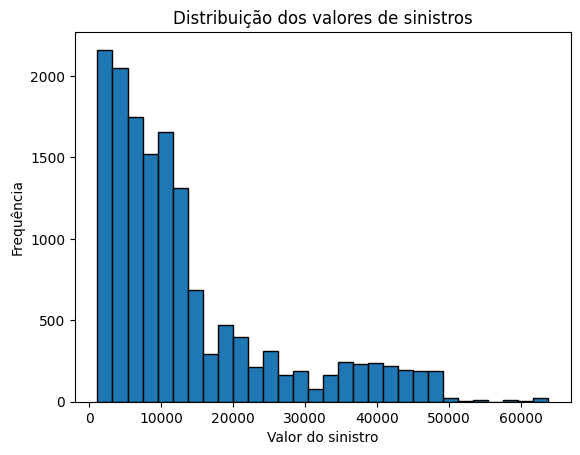

In [29]:
import matplotlib.pyplot as plt

plt.hist(dados["claim"], bins=30, edgecolor="black")
plt.xlabel("Valor do sinistro")
plt.ylabel("Frequência")
plt.title("Distribuição dos valores de sinistros")
plt.show()

In [30]:
dados["claim"].skew()

np.float64(1.4978293015042263)

In [31]:
Q1 = dados["claim"].quantile(0.25)
Q3 = dados["claim"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 4846.9
Q3: 16519.125
IQR: 11672.225


In [32]:
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)

Limite inferior: -12661.437500000002
Limite superior: 34027.4625


In [33]:
outliers_claim = dados[
    (dados["claim"] < limite_inferior) |
    (dados["claim"] > limite_superior)
]

outliers_claim.shape

(1642, 13)

In [34]:
len(outliers_claim) / len(dados) * 100

10.946666666666667

In [35]:
pd.crosstab(
    outliers_claim["smoker"],
    columns="Quantidade"
)

col_0,Quantidade
smoker,
0,48
1,1594


In [36]:
outliers_claim["smoker"].value_counts(normalize=True) * 100

,proportion
smoker,
1,97.076736
0,2.923264


In [37]:
dados.groupby("smoker")["claim"].agg(["count", "mean", "median", "min", "max"])

,count,mean,median,min,max
smoker,,,,,
0,12028,8731.296799,7512.3,1121.9,40114.8
1,2972,32301.994078,34838.9,3480.8,63770.4


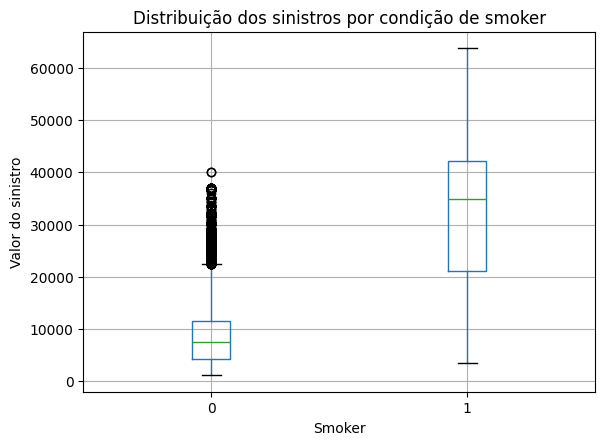

In [38]:
dados.boxplot(column="claim", by="smoker")

plt.xlabel("Smoker")
plt.ylabel("Valor do sinistro")
plt.title("Distribuição dos sinistros por condição de smoker")
plt.suptitle("")
plt.show()

### 2.1 Análise inicial da variável resposta `claim`

A variável `claim`, que representa o valor do sinistro e constitui a variável resposta do problema preditivo, apresentou média de aproximadamente 13.401,44 e mediana de 9.545,65, com valores variando entre 1.121,90 e 63.770,40.

O histograma evidenciou uma distribuição assimétrica à direita, resultado confirmado pelo coeficiente de assimetria de aproximadamente 1,50. Essa característica indica maior concentração de observações em valores menores de sinistro e a existência de uma cauda formada por valores mais elevados.

Pelo critério do intervalo interquartil (IQR), foram identificadas 1.642 observações acima do limite superior de 34.027,46, correspondendo a aproximadamente 10,95% da base. Esses registros foram considerados potenciais valores extremos para fins exploratórios, não implicando sua exclusão automática da análise.

### 2.2 Relação inicial entre `smoker` e `claim`

A análise exploratória revelou diferença expressiva no valor dos sinistros entre as categorias da variável `smoker`. Para os registros com `smoker = 0`, o valor médio do sinistro foi de aproximadamente 8.731,30 e a mediana de 7.512,30. Para `smoker = 1`, a média foi de aproximadamente 32.301,99 e a mediana de 34.838,90.

Entre as 1.642 observações classificadas como potenciais valores extremos pelo critério do IQR aplicado à distribuição geral de `claim`, 1.594 (97,08%) apresentam `smoker = 1`.

O boxplot de `claim` segundo `smoker` evidencia que os dois grupos apresentam distribuições bastante distintas. Dessa forma, os valores elevados observados na distribuição geral não devem ser interpretados automaticamente como erros ou observações inadequadas, pois parte deles parece estar associada às características de determinados grupos da carteira.

Os resultados constituem evidências exploratórias de associação entre `smoker` e o valor do sinistro. Nesta etapa, não se estabelece relação causal, e a relevância preditiva da variável deverá ser posteriormente avaliada durante a modelagem.

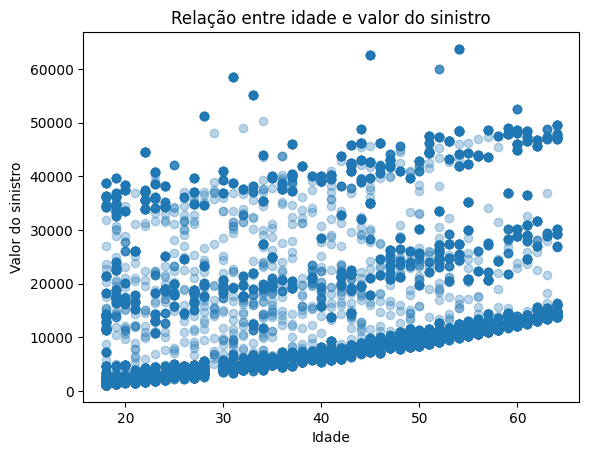

In [39]:
plt.scatter(dados["age"], dados["claim"], alpha=0.3)

plt.xlabel("Idade")
plt.ylabel("Valor do sinistro")
plt.title("Relação entre idade e valor do sinistro")
plt.show()

In [40]:
dados[["age", "claim"]].corr()

,age,claim
age,1.000000,0.301158
claim,0.301158,1.000000


In [41]:
dados.groupby("smoker")[["age", "claim"]].corr()

age     claim
smoker                          
0      age    1.000000  0.592407
       claim  0.592407  1.000000
1      age    1.000000  0.375808
       claim  0.375808  1.000000

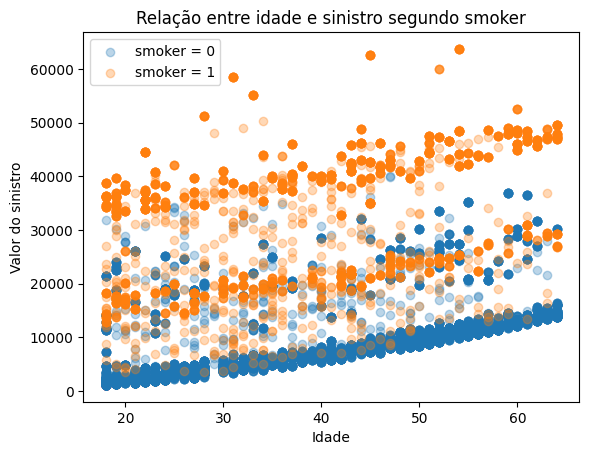

In [42]:
for grupo in [0, 1]:
    dados_grupo = dados[dados["smoker"] == grupo]

    plt.scatter(
        dados_grupo["age"],
        dados_grupo["claim"],
        alpha=0.3,
        label=f"smoker = {grupo}"
    )

plt.xlabel("Idade")
plt.ylabel("Valor do sinistro")
plt.title("Relação entre idade e sinistro segundo smoker")
plt.legend()
plt.show()

### 2.3 Relação entre idade e valor do sinistro

A análise gráfica entre `age` e `claim` indicou tendência de crescimento do valor do sinistro com o aumento da idade. Considerando conjuntamente todos os registros, a correlação linear de Pearson entre as duas variáveis foi de aproximadamente 0,301, indicando associação linear positiva.

Entretanto, o gráfico de dispersão revelou a presença de diferentes grupos de observações. Ao analisar a relação entre idade e sinistro separadamente segundo a variável `smoker`, a correlação foi de aproximadamente 0,592 para `smoker = 0` e 0,376 para `smoker = 1`.

A segmentação também evidenciou que os registros com `smoker = 1` se concentram, de modo geral, em níveis mais elevados de sinistro. Esses resultados sugerem que o valor de `claim` está relacionado simultaneamente a diferentes características dos segurados, reforçando a pertinência de uma abordagem preditiva multivariada.

As associações observadas são de natureza exploratória e não devem ser interpretadas como relações causais.

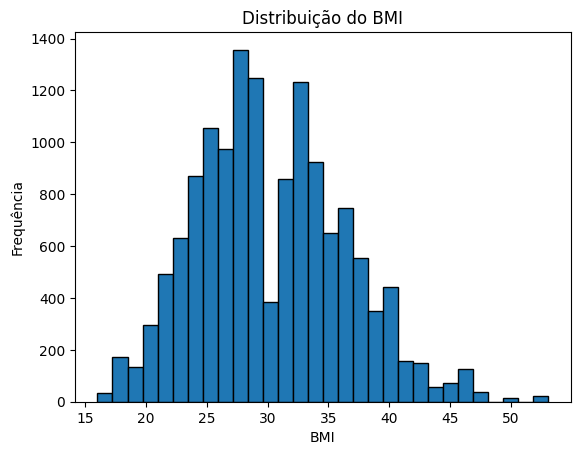

In [43]:
plt.hist(dados["bmi"].dropna(), bins=30, edgecolor="black")

plt.xlabel("BMI")
plt.ylabel("Frequência")
plt.title("Distribuição do BMI")
plt.show()

In [44]:
print("Média:", dados["bmi"].mean())
print("Mediana:", dados["bmi"].median())
print("Assimetria:", dados["bmi"].skew())

Média: 30.266412702933636
Mediana: 29.4
Assimetria: 0.3752585894901583


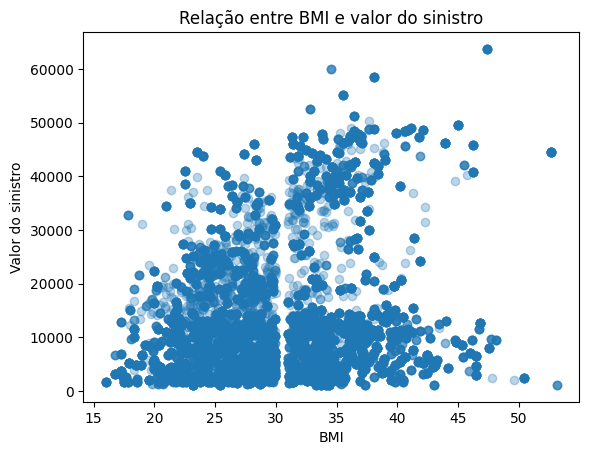

In [45]:
plt.scatter(dados["bmi"], dados["claim"], alpha=0.3)

plt.xlabel("BMI")
plt.ylabel("Valor do sinistro")
plt.title("Relação entre BMI e valor do sinistro")
plt.show()

In [46]:
dados[["bmi", "claim"]].corr()

,bmi,claim
bmi,1.000000,0.206588
claim,0.206588,1.000000


In [47]:
dados.groupby("smoker")[["bmi", "claim"]].corr()

bmi     claim
smoker                          
0      bmi    1.000000  0.129871
       claim  0.129871  1.000000
1      bmi    1.000000  0.679270
       claim  0.679270  1.000000

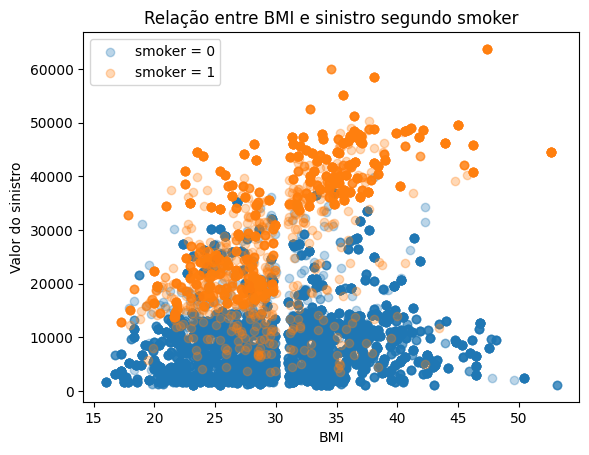

In [48]:
for grupo in [0, 1]:
    dados_grupo = dados[dados["smoker"] == grupo]

    plt.scatter(
        dados_grupo["bmi"],
        dados_grupo["claim"],
        alpha=0.3,
        label=f"smoker = {grupo}"
    )

plt.xlabel("BMI")
plt.ylabel("Valor do sinistro")
plt.title("Relação entre BMI e sinistro segundo smoker")
plt.legend()
plt.show()

### 2.4 Relação entre BMI e valor do sinistro

A variável `bmi` apresentou média de aproximadamente 30,27 e mediana de 29,4. Sua distribuição apresentou leve assimetria positiva, com coeficiente de assimetria de aproximadamente 0,375. A análise dessa variável considera 14.044 observações, uma vez que existem 956 valores ausentes de `bmi`.

Considerando conjuntamente os registros disponíveis, a correlação linear de Pearson entre `bmi` e `claim` foi de aproximadamente 0,207, indicando uma associação linear positiva relativamente baixa.

Entretanto, a análise segundo a variável `smoker` revelou comportamentos distintos. Entre os registros com `smoker = 0`, a correlação entre `bmi` e `claim` foi de aproximadamente 0,130, enquanto entre aqueles com `smoker = 1` a correlação foi de aproximadamente 0,679.

O gráfico de dispersão reforça essa diferença, mostrando uma relação crescente entre BMI e valor do sinistro mais evidente no grupo `smoker = 1`. Os resultados sugerem a existência de uma possível interação entre `bmi` e `smoker`, hipótese que poderá ser avaliada posteriormente durante a modelagem preditiva.

As associações identificadas nesta etapa possuem caráter exploratório e não implicam relação causal.

In [49]:
dados["bloodpressure"].value_counts().sort_index().head(10)

,count
bloodpressure,
0,756
40,13
41,1
42,2
44,70
46,31
48,110
49,1
50,226


In [50]:
pd.crosstab(
    dados["bloodpressure"] == 0,
    dados["bmi"].isnull()
)

bmi,False,True
bloodpressure,,
False,13344,900
True,700,56


In [51]:
pd.crosstab(
    dados["bloodpressure"] == 0,
    dados["age"].isnull()
)

age,False,True
bloodpressure,,
False,13858,386
True,746,10


In [52]:
media_com_zero = dados["bloodpressure"].mean()

media_sem_zero = dados.loc[
    dados["bloodpressure"] > 0,
    "bloodpressure"
].mean()

print("Média incluindo os zeros:", media_com_zero)
print("Média considerando apenas valores maiores que zero:", media_sem_zero)

Média incluindo os zeros: 68.65013333333333
Média considerando apenas valores maiores que zero: 72.29373771412524


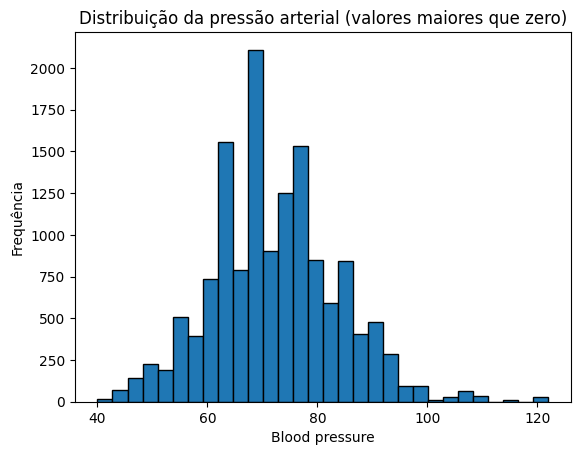

In [53]:
plt.hist(
    dados.loc[dados["bloodpressure"] > 0, "bloodpressure"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Blood pressure")
plt.ylabel("Frequência")
plt.title("Distribuição da pressão arterial (valores maiores que zero)")
plt.show()

In [54]:
assimetria_com_zero = dados["bloodpressure"].skew()

assimetria_sem_zero = dados.loc[
    dados["bloodpressure"] > 0,
    "bloodpressure"
].skew()

print("Assimetria incluindo zeros:", assimetria_com_zero)
print("Assimetria sem os zeros:", assimetria_sem_zero)

Assimetria incluindo zeros: -1.9638790071826926
Assimetria sem os zeros: 0.3378978425847468


In [55]:
correlacao_com_zero = dados[["bloodpressure", "claim"]].corr().loc[
    "bloodpressure", "claim"
]

correlacao_com_zero

np.float64(0.013742209008143706)

In [56]:
dados_bp_validos = dados[dados["bloodpressure"] > 0]

correlacao_sem_zero = dados_bp_validos[
    ["bloodpressure", "claim"]
].corr().loc["bloodpressure", "claim"]

correlacao_sem_zero

np.float64(0.038900179938393196)

### 2.5 Análise da variável `bloodpressure`

A variável `bloodpressure` não apresenta valores ausentes segundo a identificação convencional de valores nulos. Entretanto, foram encontrados 756 registros com valor igual a zero, correspondentes a aproximadamente 5,04% da base.

Como o valor zero pode representar uma codificação especial ou um valor inadequado para a medida representada pela variável, esses registros foram mantidos nesta etapa, mas identificados para investigação e tratamento posterior.

A presença dos zeros afetou de forma relevante algumas estatísticas descritivas. A média de `bloodpressure` foi de aproximadamente 68,65 quando considerados todos os registros e de 72,29 quando considerados apenas valores maiores que zero. Da mesma forma, o coeficiente de assimetria passou de aproximadamente -1,964, incluindo os zeros, para 0,338 quando considerados somente valores positivos.

A correlação linear entre `bloodpressure` e `claim` foi de aproximadamente 0,014 considerando todos os registros e 0,039 considerando apenas valores positivos. Assim, não foi observada, nesta análise exploratória, associação linear relevante entre as duas variáveis.

A natureza dos valores iguais a zero deverá ser investigada antes da etapa de modelagem, evitando tratá-los automaticamente como medidas válidas ou como valores ausentes sem justificativa.

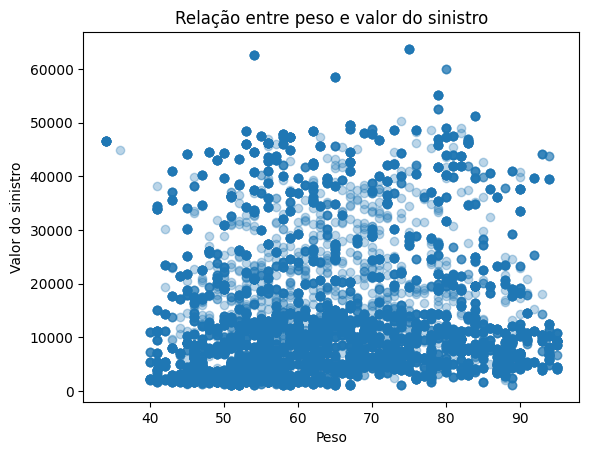

In [57]:
plt.scatter(dados["weight"], dados["claim"], alpha=0.3)

plt.xlabel("Peso")
plt.ylabel("Valor do sinistro")
plt.title("Relação entre peso e valor do sinistro")
plt.show()

In [58]:
dados[["weight", "claim"]].corr()

,weight,claim
weight,1.000000,0.077716
claim,0.077716,1.000000


In [59]:
dados.groupby("smoker")[["weight", "claim"]].corr()

weight     claim
smoker                           
0      weight  1.000000  0.137907
       claim   0.137907  1.000000
1      weight  1.000000  0.046715
       claim   0.046715  1.000000

In [60]:
dados[["weight", "bmi"]].corr()

,weight,bmi
weight,1.000000,0.251649
bmi,0.251649,1.000000


In [61]:
dados.groupby("no_of_dependents")["claim"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
no_of_dependents,,,
0,6290,12336.580541,9866.3
1,3625,13107.560552,8539.7
2,2721,15203.368725,9630.4
3,1820,15527.063187,11085.6
4,301,13965.550166,11299.3
5,243,8552.731687,8582.3


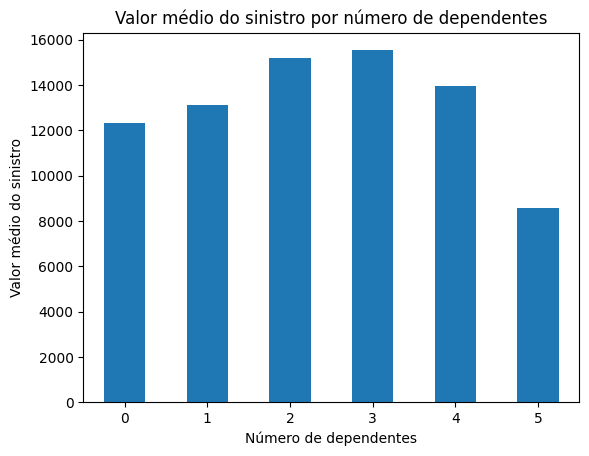

In [62]:
media_dependentes = dados.groupby("no_of_dependents")["claim"].mean()

media_dependentes.plot(kind="bar")

plt.xlabel("Número de dependentes")
plt.ylabel("Valor médio do sinistro")
plt.title("Valor médio do sinistro por número de dependentes")
plt.xticks(rotation=0)
plt.show()

In [63]:
pd.crosstab(
    dados["no_of_dependents"],
    dados["smoker"],
    normalize="index"
) * 100

smoker,0,1
no_of_dependents,,
0,81.589825,18.410175
1,79.834483,20.165517
2,77.912532,22.087468
3,75.494505,24.505495
4,89.368771,10.631229
5,98.353909,1.646091


In [64]:
dados.groupby(
    ["no_of_dependents", "smoker"]
)["claim"].mean().unstack()

smoker,0,1
no_of_dependents,,
0,7977.182210,31656.470207
1,8438.834554,31590.861560
2,9763.474104,34392.348087
3,9893.803275,32881.545516
4,12506.617844,26229.700000
5,8377.492050,19023.300000


In [65]:
pd.crosstab(
    dados["no_of_dependents"],
    dados["smoker"]
)

smoker,0,1
no_of_dependents,,
0,5132,1158
1,2894,731
2,2120,601
3,1374,446
4,269,32
5,239,4


### 2.6 Relação de `weight` e `no_of_dependents` com o valor do sinistro

A variável `weight` apresentou correlação linear positiva muito baixa com `claim`, de aproximadamente 0,078. Quando a análise foi realizada separadamente segundo `smoker`, as correlações permaneceram baixas, sendo aproximadamente 0,138 para `smoker = 0` e 0,047 para `smoker = 1`.

Embora `weight` e `bmi` estejam conceitualmente relacionados, a correlação linear observada entre essas variáveis foi de aproximadamente 0,252. Dessa forma, não há evidência, nesta etapa exploratória, de que as duas variáveis sejam suficientemente redundantes para justificar a exclusão de uma delas apenas com base nessa correlação.

Para `no_of_dependents`, o valor médio de `claim` apresentou comportamento não monotônico. A média cresceu de aproximadamente 12.336,58 para segurados sem dependentes até 15.527,06 para aqueles com três dependentes, diminuindo posteriormente para 13.965,55 com quatro e 8.552,73 com cinco dependentes.

A composição dos grupos segundo `smoker` apresentou diferenças relevantes. A proporção de `smoker = 1` aumentou de 18,41% entre os registros sem dependentes para 24,51% entre aqueles com três dependentes, enquanto caiu para 10,63% com quatro dependentes e 1,65% com cinco.

Após separar os registros segundo `smoker`, não foi identificado um padrão monotônico consistente entre número de dependentes e valor médio do sinistro. Além disso, algumas combinações possuem poucas observações, especialmente `5 dependentes + smoker = 1`, com apenas quatro registros, tornando sua média particularmente instável.

Esses resultados indicam que a associação observada inicialmente entre `no_of_dependents` e `claim` pode estar parcialmente relacionada à composição dos grupos segundo outras características, especialmente `smoker`. A utilidade preditiva da variável deverá ser avaliada posteriormente no contexto multivariado.

In [66]:
dados.groupby("sex")["claim"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
sex,,,,,
female,7652,12692.053515,9432.9,1607.5,63770.4
male,7348,14140.170223,9617.7,1121.9,62592.9


In [67]:
pd.crosstab(
    dados["sex"],
    dados["smoker"],
    normalize="index"
) * 100

smoker,0,1
sex,,
female,83.076320,16.923680
male,77.177463,22.822537


In [68]:
dados.groupby(
    ["sex", "smoker"]
)["claim"].mean().unstack()

smoker,0,1
sex,,
female,8968.232594,30971.844710
male,8465.699753,33329.151759


### 2.7 Relação entre `sex` e valor do sinistro

A análise inicial segundo `sex` mostrou valor médio de `claim` de aproximadamente 12.692,05 para `female` e 14.140,17 para `male`. As medianas, entretanto, foram mais próximas, correspondendo a 9.432,90 e 9.617,70, respectivamente.

A composição dos dois grupos segundo `smoker` apresentou diferenças. Entre os registros classificados como `female`, aproximadamente 16,92% apresentam `smoker = 1`, enquanto entre os classificados como `male` essa proporção é de aproximadamente 22,82%.

Ao comparar o valor médio de `claim` separadamente segundo `smoker`, a diferença entre os sexos apresentou comportamento distinto. Entre os registros com `smoker = 0`, as médias foram aproximadamente 8.968,23 para `female` e 8.465,70 para `male`. Entre aqueles com `smoker = 1`, as médias foram aproximadamente 30.971,84 e 33.329,15, respectivamente.

Os resultados mostram que a diferença observada inicialmente entre os valores médios de `claim` segundo `sex` deve ser interpretada considerando também a composição dos grupos em relação a outras características, especialmente `smoker`. A eventual contribuição preditiva de `sex` será avaliada posteriormente em conjunto com as demais variáveis do modelo.

In [69]:
dados.groupby("diabetes")["claim"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
diabetes,,,,,
0,3345,10331.827743,7639.4,1131.5,60021.4
1,11655,14282.419605,10118.4,1121.9,63770.4


In [70]:
pd.crosstab(
    dados["diabetes"],
    dados["smoker"],
    normalize="index"
) * 100

smoker,0,1
diabetes,,
0,84.514200,15.485800
1,78.944659,21.055341


In [71]:
dados.groupby(
    ["diabetes", "smoker"]
)["claim"].mean().unstack()

smoker,0,1
diabetes,,
0,8080.882526,22616.426448
1,8931.136072,34346.461899


In [72]:
dados.groupby("diabetes")["age"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
diabetes,,,,,
0,3243,37.694419,36.0,18.0,64.0
1,11361,40.076490,41.0,18.0,64.0


### 2.8 Relação entre `diabetes` e valor do sinistro

De acordo com a documentação original do conjunto de dados, a variável `diabetes` é binária, sendo `0` correspondente a segurado não diabético e `1` a segurado diabético. Na base analisada, 3.345 registros (22,30%) pertencem ao grupo `diabetes = 0` e 11.655 (77,70%) ao grupo `diabetes = 1`.

O valor médio de `claim` foi de aproximadamente 10.331,83 entre os não diabéticos e 14.282,42 entre os diabéticos. As medianas também foram maiores no segundo grupo, correspondendo a 7.639,40 e 10.118,40, respectivamente.

A composição dos grupos segundo `smoker` apresentou diferenças. Entre os não diabéticos, aproximadamente 15,49% são fumantes, enquanto entre os diabéticos essa proporção é de aproximadamente 21,06%.

Após separar os registros segundo `smoker`, os diabéticos continuaram apresentando maior valor médio de `claim` nos dois grupos. Entre os não fumantes, as médias foram aproximadamente 8.080,88 para não diabéticos e 8.931,14 para diabéticos. Entre os fumantes, as médias foram aproximadamente 22.616,43 e 34.346,46, respectivamente.

A diferença entre diabéticos e não diabéticos foi, portanto, consideravelmente maior entre os fumantes. Esse resultado sugere uma possível interação entre `diabetes` e `smoker`, hipótese que poderá ser posteriormente avaliada durante a modelagem preditiva.

Também foram observadas diferenças de idade entre os grupos. Os não diabéticos apresentaram idade média de aproximadamente 37,69 anos e mediana de 36 anos, enquanto os diabéticos apresentaram média de 40,08 anos e mediana de 41 anos. Dessa forma, outras características dos segurados, como idade, também devem ser consideradas na interpretação das associações observadas.

Os resultados possuem caráter exploratório e não devem ser interpretados como evidência de relações causais.

In [73]:
dados.groupby("regular_ex")["claim"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
regular_ex,,,,,
0,11638,13796.399562,9304.70,1121.9,63770.4
1,3362,12034.225521,9871.25,1135.9,48950.1


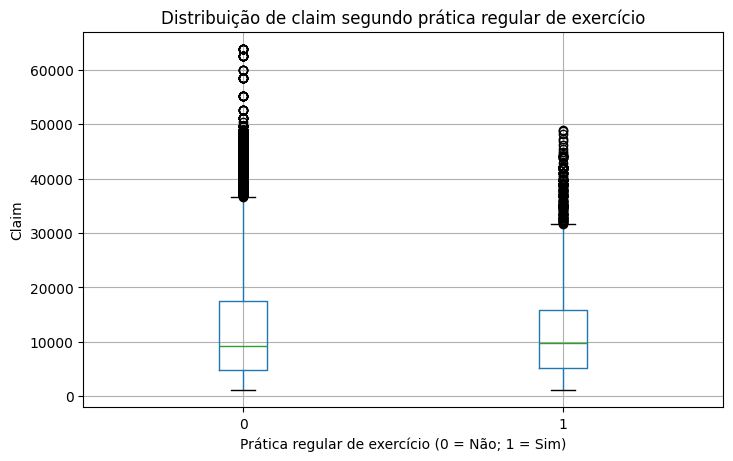

In [74]:
import matplotlib.pyplot as plt

dados.boxplot(
    column="claim",
    by="regular_ex",
    figsize=(8, 5)
)

plt.title("Distribuição de claim segundo prática regular de exercício")
plt.suptitle("")
plt.xlabel("Prática regular de exercício (0 = Não; 1 = Sim)")
plt.ylabel("Claim")
plt.show()

In [75]:
dados.assign(
    claim_alto=dados["claim"] > 34027.4625
).groupby("regular_ex")["claim_alto"].agg(
    ["count", "sum", "mean"]
)

,count,sum,mean
regular_ex,,,
0,11638,1500,0.128888
1,3362,142,0.042237


In [76]:
pd.crosstab(
    dados["regular_ex"],
    dados["smoker"],
    normalize="index"
) * 100

smoker,0,1
regular_ex,,
0,79.395085,20.604915
1,82.926829,17.073171


In [77]:
pd.crosstab(
    dados["regular_ex"],
    dados["diabetes"],
    normalize="index"
) * 100

diabetes,0,1
regular_ex,,
0,22.478089,77.521911
1,21.683522,78.316478


In [78]:
dados.groupby(
    ["smoker", "diabetes", "regular_ex"]
)["claim"].agg(
    ["count", "mean", "median"]
)

count          mean    median
smoker diabetes regular_ex                               
0      0        0            2270   7667.434802   5966.90
                1             557   9765.849013   8551.40
       1        0            6970   8782.436772   7731.40
                1            2231   9395.696414   8310.80
1      0        0             346  24440.287283  22629.05
                1             172  18947.497093  17591.00
       1        0            2052  35812.620565  38344.60
                1             402  26862.487811  23967.40

In [79]:
dados.groupby(
    ["smoker", "regular_ex"]
)["age"].agg(
    ["count", "mean", "median"]
)

count       mean  median
smoker regular_ex                          
0      0            8972  39.486068    40.0
       1            2718  40.341060    41.0
1      0            2344  39.470990    41.0
       1             570  37.045614    36.0

### 2.9 Relação entre `regular_ex` e valor do sinistro

De acordo com a documentação do conjunto de dados, `regular_ex = 0` indica que o segurado não pratica exercício regularmente, enquanto `regular_ex = 1` indica prática regular de exercício.

Na análise inicial, o valor médio de `claim` foi de aproximadamente 13.796,40 entre os segurados que não praticam exercício regularmente e 12.034,23 entre aqueles que praticam. Entretanto, as medianas apresentaram comportamento inverso, correspondendo a 9.304,70 e 9.871,25, respectivamente.

A distribuição de `claim` mostrou maior presença proporcional de valores elevados no grupo que não pratica exercício regularmente. Utilizando como referência o limite superior de 34.027,46 obtido anteriormente pelo critério do intervalo interquartil, aproximadamente 12,89% dos registros com `regular_ex = 0` apresentaram valores acima desse limite, contra 4,22% entre aqueles com `regular_ex = 1`.

A composição dos grupos apresentou diferença quanto ao tabagismo. Entre aqueles que não praticam exercício regularmente, aproximadamente 20,60% são fumantes, contra 17,07% entre os que praticam. Em relação a `diabetes`, entretanto, as proporções foram semelhantes: aproximadamente 77,52% e 78,32%, respectivamente.

Ao comparar `regular_ex` dentro de combinações de `smoker` e `diabetes`, não foi observado um comportamento uniforme. Entre os não fumantes, os segurados que praticam exercício regularmente apresentaram maior valor médio de `claim`, tanto entre diabéticos quanto entre não diabéticos. Entre os fumantes, ocorreu o comportamento inverso, com maiores valores médios entre aqueles que não praticam exercício regularmente.

Esse resultado sugere que a associação entre `regular_ex` e `claim` pode depender de outras características dos segurados, especialmente `smoker`, indicando uma possível interação a ser posteriormente investigada durante a modelagem.

A idade média apresentou pouca diferença segundo a prática de exercício entre os não fumantes. Entre os fumantes, aqueles que não praticam exercício regularmente apresentaram idade média superior, aproximadamente 39,47 anos contra 37,05 anos entre os que praticam, o que também pode contribuir para as diferenças observadas.

Os resultados possuem caráter exploratório e não permitem estabelecer relações causais.

In [80]:
dados.groupby("hereditary_diseases")["claim"].agg(
    ["count", "mean", "median"]
).sort_values("mean", ascending=False)

,count,mean,median
hereditary_diseases,,,
HeartDisease,93,43084.513978,40419.0
EyeDisease,123,41343.987805,42760.5
High BP,69,40670.046377,41661.6
Epilepsy,84,39937.767857,42983.5
Diabetes,148,39648.689189,39769.0
Obesity,136,39589.258824,42211.1
Cancer,109,39510.742202,38746.4
Alzheimer,144,37562.870139,38998.6
Arthritis,96,34092.977083,35595.6


In [81]:
pd.crosstab(
    dados["hereditary_diseases"],
    dados["smoker"],
    normalize="index"
) * 100

smoker,0,1
hereditary_diseases,,
Alzheimer,10.416667,89.583333
Arthritis,3.125000,96.875000
Cancer,18.348624,81.651376
Diabetes,1.351351,98.648649
Epilepsy,4.761905,95.238095
EyeDisease,5.691057,94.308943
HeartDisease,11.827957,88.172043
High BP,0.000000,100.000000
NoDisease,85.433633,14.566367


In [82]:
dados.groupby(
    ["hereditary_diseases", "smoker"]
)["claim"].agg(
    ["count", "mean", "median"]
)

count          mean   median
hereditary_diseases smoker                              
Alzheimer           0          15  30086.820000  32108.7
                    1         129  38432.178295  39556.5
Arthritis           0           3  19195.333333  14219.2
                    1          93  34573.546237  35595.6
Cancer              0          20  28087.005000  30284.6
                    1          89  42077.874157  42112.2
Diabetes            0           2  16187.600000  16187.6
                    1         146  39970.073973  39774.3
Epilepsy            0           4  18731.825000  18789.5
                    1          80  40998.065000  42983.5
EyeDisease          0           7  19695.942857  18035.4
                    1         116  42650.335345  42760.5
HeartDisease        0          11  36580.300000  36580.3
                    1          82  43957.030488  44501.4
High BP             1          69  40670.046377  41661.6
NoDisease           0       11959   8625.338615   7441.5
                    1        2039  28630.293575  24869.8
Obesity             0           7  21632.514286  24874.6
                    1         129  40563.655814  42211.1

In [83]:
pd.crosstab(
    dados["hereditary_diseases"],
    dados["diabetes"],
    normalize="index"
) * 100

diabetes,0,1
hereditary_diseases,,
Alzheimer,2.777778,97.222222
Arthritis,15.625000,84.375000
Cancer,5.504587,94.495413
Diabetes,4.054054,95.945946
Epilepsy,21.428571,78.571429
EyeDisease,15.447154,84.552846
HeartDisease,0.000000,100.000000
High BP,7.246377,92.753623
NoDisease,23.203315,76.796685


### 2.10 Relação entre `hereditary_diseases` e valor do sinistro

A variável `hereditary_diseases` apresenta forte desbalanceamento entre suas categorias. Dos 15.000 registros da base, 13.998 (93,32%) pertencem à categoria `NoDisease`, enquanto as demais categorias possuem entre 69 e 148 observações.

Na análise inicial, todas as categorias de doença apresentaram valores médios de `claim` substancialmente superiores ao grupo `NoDisease`. Enquanto a média de `claim` para `NoDisease` foi de aproximadamente 11.539,33, as médias das demais categorias variaram entre aproximadamente 34.092,98 (`Arthritis`) e 43.084,51 (`HeartDisease`).

Entretanto, foi identificada forte associação entre `hereditary_diseases` e `smoker`. Apenas aproximadamente 14,57% dos registros classificados como `NoDisease` são fumantes, enquanto nas demais categorias a proporção de fumantes variou de aproximadamente 81,65% a 100%.

Após restringir a comparação aos fumantes, as categorias de doença continuaram apresentando valores médios de `claim` superiores ao grupo `NoDisease`. Entre os fumantes classificados como `NoDisease`, a média foi de aproximadamente 28.630,29, enquanto nas demais categorias variou de aproximadamente 34.573,55 (`Arthritis`) a 43.957,03 (`HeartDisease`). Esse resultado indica que a diferença inicialmente observada não parece estar associada exclusivamente à composição dos grupos segundo `smoker`.

A comparação entre não fumantes deve ser interpretada com cautela, pois as categorias de doença possuem amostras muito pequenas nesse grupo. Algumas combinações apresentam apenas dois ou três registros, e a categoria `High BP` não possui observações com `smoker = 0`.

Em relação à variável binária `diabetes`, foram observadas diferenças menos acentuadas entre as categorias. A proporção de `diabetes = 1` foi de aproximadamente 76,80% em `NoDisease` e variou de 78,57% a 100% nas demais categorias.

Também foi observado que a categoria `Diabetes` de `hereditary_diseases` não corresponde diretamente à variável binária `diabetes`. Existem registros classificados como `hereditary_diseases = Diabetes` com `diabetes = 0`, assim como grande quantidade de registros classificados como `NoDisease` com `diabetes = 1`. Dessa forma, as duas variáveis serão tratadas como informações distintas, preservando a classificação existente na base.

Os resultados sugerem que `hereditary_diseases` pode conter informação relevante para a predição de `claim`. Entretanto, o forte desbalanceamento das categorias e sua associação com outras variáveis, especialmente `smoker`, deverão ser considerados na etapa de modelagem.

In [84]:
contagem_city = dados["city"].value_counts()

contagem_city.describe()

,count
count,91.000000
mean,164.835165
std,66.620361
min,69.000000
25%,118.500000
50%,136.000000
75%,199.000000
max,302.000000


In [85]:
claim_city = dados.groupby("city")["claim"].agg(
    ["count", "mean", "median"]
).sort_values("mean", ascending=False)

claim_city.head(10)

,count,mean,median
city,,,
Indianapolis,121,16125.491736,11033.70
Huntsville,96,15930.980208,10986.45
SantaRosa,103,15846.629126,11125.50
Kingman,199,15532.600000,10965.50
Youngstown,103,15345.605825,10844.40
Mandan,121,15237.184298,11073.20
Eureka,103,15163.148544,9880.10
Montrose,198,15161.577778,10597.40
Chicago,116,14851.149138,9972.75


In [86]:
claim_city.tail(10)

,count,mean,median
city,,,
Brimingham,298,11925.010738,7729.70
Brookings,116,11855.802586,8603.35
Miami,122,11819.338525,9290.10
Baltimore,69,11678.333333,8891.10
Cincinnati,121,11573.261983,9304.70
Escabana,103,11571.848544,7418.50
Salina,116,11528.765517,8725.75
SanFrancisco,103,11404.491262,7627.00
Lincoln,116,11102.485345,8283.70


In [87]:
proporcao_fumantes_city = dados.groupby("city")["smoker"].mean() * 100

claim_city["fumantes_%"] = proporcao_fumantes_city

claim_city.head(10)

,count,mean,median,fumantes_%
city,,,,
Indianapolis,121,16125.491736,11033.70,24.793388
Huntsville,96,15930.980208,10986.45,23.958333
SantaRosa,103,15846.629126,11125.50,30.097087
Kingman,199,15532.600000,10965.50,26.633166
Youngstown,103,15345.605825,10844.40,26.213592
Mandan,121,15237.184298,11073.20,24.793388
Eureka,103,15163.148544,9880.10,24.271845
Montrose,198,15161.577778,10597.40,22.222222
Chicago,116,14851.149138,9972.75,19.827586


In [88]:
claim_city["mean"].corr(claim_city["fumantes_%"])

np.float64(0.7606705549061602)

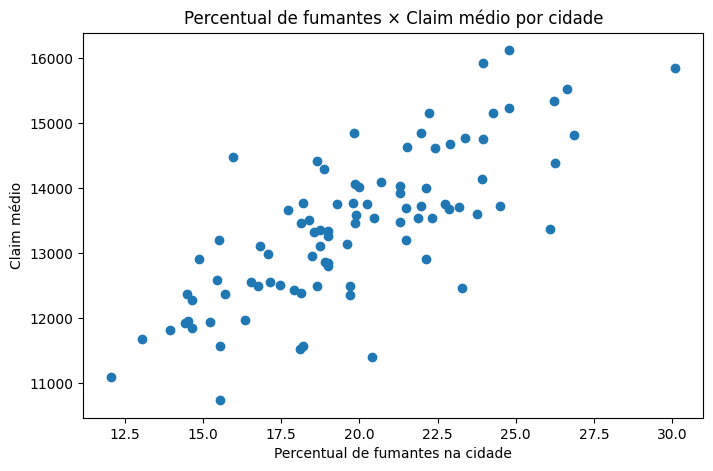

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    claim_city["fumantes_%"],
    claim_city["mean"]
)

plt.xlabel("Percentual de fumantes na cidade")
plt.ylabel("Claim médio")
plt.title("Percentual de fumantes × Claim médio por cidade")

plt.show()

In [90]:
city_nao_fumantes = (
    dados[dados["smoker"] == 0]
    .groupby("city")["claim"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

city_nao_fumantes.head(10)

,count,mean,median
city,,,
Warwick,58,10685.222414,9814.40
Buffalo,109,10396.610092,8627.50
Oceanside,162,10109.894444,8087.40
Chicago,93,9978.458065,7985.80
Harrisburg,226,9818.559292,8610.75
Indianapolis,91,9755.913187,6940.90
Kingsport,95,9755.626316,7935.30
Montrose,154,9725.936364,8883.10
Reno,142,9674.755634,8536.35


In [91]:
city_nao_fumantes.tail(10)

,count,mean,median
city,,,
Brookings,99,8121.346465,7050.00
SantaFe,142,8059.097183,5946.75
Newport,213,8048.623474,7147.50
JeffersonCity,85,7947.705882,7954.50
Prescott,111,7821.048649,6940.90
York,51,7768.541176,6555.10
KanasCity,89,7647.576404,6455.90
Escabana,87,7546.235632,5385.30
Salina,95,7471.866316,6600.40


In [92]:
city_fumantes = (
    dados[dados["smoker"] == 1]
    .groupby("city")["claim"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

city_fumantes.head(10)

,count,mean,median
city,,,
Waterloo,18,38927.750000,40607.50
Huntsville,23,36392.343478,36907.70
Tampa,26,35586.561538,38604.10
Orlando,17,35537.305882,37742.60
Cambridge,27,35528.877778,39727.60
Portland,21,35482.847619,41949.20
Indianapolis,30,35446.546667,38353.35
Houston,51,34921.382353,36149.50
Hartford,25,34916.720000,37829.70


In [93]:
city_fumantes.tail(10)

,count,mean,median
city,,,
Trenton,10,29240.890000,28700.05
Pheonix,29,29219.751724,26125.70
Worcester,60,29139.048333,24551.90
SanDeigo,39,29026.553846,24520.30
Kingsport,27,28993.392593,31845.30
KanasCity,27,28369.103704,28567.30
SanFrancisco,21,27551.342857,20773.60
Columbia,19,26954.857895,22478.60
Cincinnati,22,26731.095455,24622.70


In [94]:
city_nao_fumantes["mean"].describe()

,mean
count,91.000000
mean,8730.208102
std,632.502262
min,7269.321951
25%,8306.436497
50%,8643.071548
75%,9074.528052
max,10685.222414


In [95]:
city_fumantes["mean"].describe()

,mean
count,91.000000
mean,32268.849287
std,2361.563531
min,24108.306250
25%,30756.084435
50%,32497.148387
75%,33981.707511
max,38927.750000


In [96]:
sorted(dados["city"].unique())

['Atlanta',
 'AtlanticCity',
 'Bakersfield',
 'Baltimore',
 'Bloomington',
 'Boston',
 'Brimingham',
 'Brookings',
 'Buffalo',
 'Cambridge',
 'Canton',
 'Carlsbad',
 'Charleston',
 'Charlotte',
 'Chicago',
 'Cincinnati',
 'Cleveland',
 'Columbia',
 'Columbus',
 'Denver',
 'Escabana',
 'Eureka',
 'FallsCity',
 'Fargo',
 'Florence',
 'Fresno',
 'Georgia',
 'GrandForks',
 'Harrisburg',
 'Hartford',
 'Houston',
 'Huntsville',
 'Indianapolis',
 'IowaCity',
 'JeffersonCity',
 'KanasCity',
 'Kingman',
 'Kingsport',
 'Knoxville',
 'LasVegas',
 'Lincoln',
 'LosAngeles',
 'Louisville',
 'Lovelock',
 'Macon',
 'Mandan',
 'Marshall',
 'Memphis',
 'Mexicali',
 'Miami',
 'Minneapolis',
 'Minot',
 'Montrose',
 'Nashville',
 'NewOrleans',
 'NewYork',
 'Newport',
 'Oceanside',
 'Oklahoma',
 'Orlando',
 'Oxnard',
 'PanamaCity',
 'Pheonix',
 'Phildelphia',
 'Pittsburg',
 'Portland',
 'Prescott',
 'Providence',
 'Raleigh',
 'Reno',
 'Rochester',
 'Salina',
 'SanDeigo',
 'SanFrancisco',
 'SanJose',
 'SanLu

### 2.11 Relação entre `city` e valor do sinistro

A variável `city` apresenta 91 categorias, com número de observações por categoria variando entre 69 e 302. Na análise inicial, foram observadas diferenças nos valores médios de `claim` entre as cidades. A maior média foi de aproximadamente 16.125,49 e a menor de 10.742,25, correspondendo a uma amplitude de aproximadamente 5.383,24.

Entretanto, a composição das cidades em relação à variável `smoker` mostrou-se relevante para a interpretação dessas diferenças. A correlação entre o percentual de fumantes em cada cidade e o valor médio de `claim` foi de aproximadamente 0,761, indicando forte associação positiva em nível agregado.

Ao restringir a análise aos não fumantes, as médias municipais variaram entre aproximadamente 7.269,32 e 10.685,22, com desvio-padrão de 632,50. Os 50% centrais das médias das cidades ficaram entre aproximadamente 8.306,44 e 9.074,53.

Entre os fumantes, as médias municipais variaram entre aproximadamente 24.108,31 e 38.927,75, com desvio-padrão de 2.361,56. Os 50% centrais ficaram entre aproximadamente 30.756,08 e 33.981,71. Entretanto, as estimativas para esse grupo devem ser interpretadas com maior cautela, pois o número de fumantes em diversas cidades é relativamente pequeno, tornando as médias municipais mais sensíveis a observações individuais.

Os resultados mostram que parte das diferenças inicialmente observadas entre as cidades está associada à composição dos grupos segundo `smoker`. Contudo, as diferenças não desapareceram após a estratificação, de modo que `city` será mantida inicialmente como potencial variável preditora. Sua contribuição efetiva deverá ser avaliada posteriormente no contexto multivariado e por meio do desempenho preditivo fora da amostra.

Durante a avaliação da qualidade dos dados, também foram identificadas categorias com possíveis inconsistências de nomenclatura, como `Brimingham`, `KanasCity`, `Pheonix`, `Phildelphia` e `SanDeigo`, além de categorias como `Georgia` e `Oklahoma`, que merecem verificação quanto à natureza da localização representada. Essas categorias não foram alteradas nesta etapa, uma vez que qualquer correção deve ser fundamentada na documentação da fonte dos dados.

In [97]:
contagem_job = dados["job_title"].value_counts()

contagem_job

,count
job_title,
Student,1320
HomeMakers,972
Singer,744
Actor,720
FilmMaker,714
Dancer,693
HouseKeeper,667
Manager,602
Police,412


In [98]:
contagem_job.describe()

,count
count,35.000000
mean,428.571429
std,238.163721
min,210.000000
25%,281.000000
50%,365.000000
75%,406.000000
max,1320.000000


In [99]:
claim_job = (
    dados.groupby("job_title")["claim"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

claim_job.head(10)

,count,mean,median
job_title,,,
CEO,384,17026.727865,10807.5
Architect,365,16710.670411,10825.3
Accountant,368,16320.152717,9957.7
Journalist,275,16266.526545,10197.8
Manager,602,16043.033389,12928.8
ITProfessional,348,15685.822126,9222.4
FilmMaker,714,15541.608263,13937.7
DataScientist,335,15421.547761,9030.3
Clerks,367,15329.921798,8964.1


In [100]:
claim_job.tail(10)

,count,mean,median
job_title,,,
Student,1320,11186.299545,3597.60
FilmDirector,281,11134.662278,8342.90
GovEmployee,250,9947.415600,8233.10
Farmer,258,9854.950775,7933.15
DefencePersonnels,292,9575.998288,7623.50
Chef,281,9464.499288,8026.70
Technician,283,9208.974558,6666.20
Analyst,255,8787.665098,7627.00
Blogger,281,8577.109253,7046.70


In [101]:
proporcao_fumantes_job = (
    dados.groupby("job_title")["smoker"].mean() * 100
)

claim_job["fumantes_%"] = proporcao_fumantes_job

claim_job[["count", "mean", "median", "fumantes_%"]].head(10)

,count,mean,median,fumantes_%
job_title,,,,
CEO,384,17026.727865,10807.5,31.250000
Architect,365,16710.670411,10825.3,34.520548
Accountant,368,16320.152717,9957.7,31.521739
Journalist,275,16266.526545,10197.8,24.727273
Manager,602,16043.033389,12928.8,19.933555
ITProfessional,348,15685.822126,9222.4,24.137931
FilmMaker,714,15541.608263,13937.7,23.669468
DataScientist,335,15421.547761,9030.3,23.880597
Clerks,367,15329.921798,8964.1,25.885559


In [102]:
claim_job["mean"].corr(claim_job["fumantes_%"])

np.float64(0.8845480183941055)

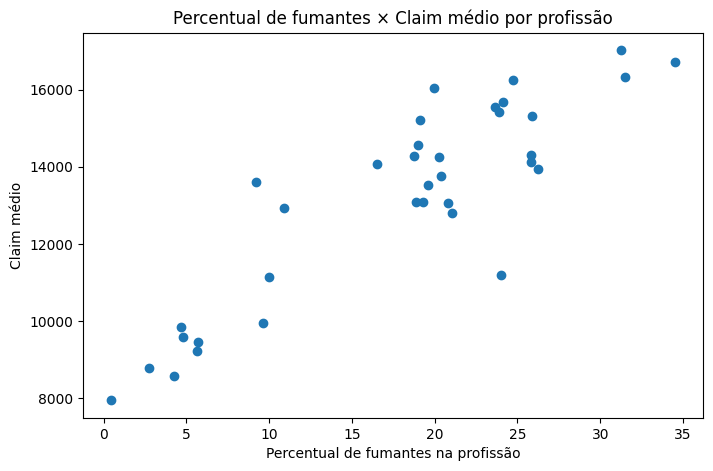

In [103]:
plt.figure(figsize=(8, 5))

plt.scatter(
    claim_job["fumantes_%"],
    claim_job["mean"]
)

plt.xlabel("Percentual de fumantes na profissão")
plt.ylabel("Claim médio")
plt.title("Percentual de fumantes × Claim médio por profissão")

plt.show()

In [104]:
job_nao_fumantes = (
    dados[dados["smoker"] == 0]
    .groupby("job_title")["claim"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

job_nao_fumantes.head(10)

,count,mean,median
job_title,,,
FilmMaker,545,12003.083853,12925.9
Manager,482,11422.577386,10407.1
Politician,336,11019.109524,8671.2
Photographer,325,10635.554769,8733.2
Doctor,262,10108.625191,9058.7
Lawyer,250,9845.753200,8116.7
HomeMakers,770,9745.015974,8835.3
FashionDesigner,301,9689.268106,7742.1
Engineer,303,9608.071287,8124.4


In [105]:
job_nao_fumantes.tail(10)

,count,mean,median
job_title,,,
DefencePersonnels,278,7729.402518,7623.5
Farmer,246,7701.498780,7633.7
Accountant,252,7692.489286,7441.1
Chef,265,7668.178113,7421.2
FilmDirector,253,7566.651779,7325.1
Academician,247,7475.858300,7147.1
GovEmployee,226,7453.443805,7639.4
Technician,267,6981.446067,6666.2
Blogger,269,6864.966914,7046.7


In [106]:
job_fumantes = (
    dados[dados["smoker"] == 1]
    .groupby("job_title")["claim"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

job_fumantes.head(10)

,count,mean,median
job_title,,,
Farmer,12,54000.716667,62592.9
Blogger,12,46957.633333,48173.4
Technician,16,46380.856250,58571.1
DefencePersonnels,14,46244.114286,55135.4
Analyst,7,46026.485714,60021.4
FilmDirector,28,43374.185714,44641.2
Journalist,68,40666.366176,39836.5
ITProfessional,84,40416.391667,39983.4
DataScientist,80,39760.252500,40273.7


In [107]:
job_fumantes.tail(10)

,count,mean,median
job_title,,,
Police,84,31683.955952,27037.90
Singer,146,30637.698630,28950.50
Photographer,75,30119.524000,24869.80
Dancer,179,28583.220112,25382.30
Beautician,81,28254.290123,21259.40
FashionDesigner,70,27658.748571,21348.70
HouseKeeper,172,27362.848837,21910.65
FilmMaker,169,26952.826036,22412.70
Actor,189,26895.161905,21771.30


In [108]:
job_nao_fumantes["mean"].describe()

,mean
count,35.000000
mean,8706.555704
std,1444.437020
min,4636.699900
25%,7715.450649
50%,8661.494301
75%,9561.381300
max,12003.083853


In [109]:
job_fumantes["mean"].describe()

,mean
count,35.000000
mean,35957.743224
std,6761.664474
min,25744.517822
25%,31160.827291
50%,35063.007759
75%,39526.676250
max,54000.716667


In [110]:
idade_media_job = dados.groupby("job_title")["age"].mean()

claim_job["idade_media"] = idade_media_job

claim_job[
    ["count", "mean", "median", "fumantes_%", "idade_media"]
].sort_values("mean", ascending=False)

,count,mean,median,fumantes_%,idade_media
job_title,,,,,
CEO,384,17026.727865,10807.50,31.250000,43.370166
Architect,365,16710.670411,10825.30,34.520548,40.708934
Accountant,368,16320.152717,9957.70,31.521739,39.725543
Journalist,275,16266.526545,10197.80,24.727273,41.806202
Manager,602,16043.033389,12928.80,19.933555,44.756803
ITProfessional,348,15685.822126,9222.40,24.137931,41.304598
FilmMaker,714,15541.608263,13937.70,23.669468,45.828530
DataScientist,335,15421.547761,9030.30,23.880597,41.953416
Clerks,367,15329.921798,8964.10,25.885559,37.058309


In [111]:
claim_job["mean"].corr(claim_job["idade_media"])

np.float64(0.32321717521970905)

In [112]:
claim_job_sem_student = claim_job.drop(index="Student")

claim_job_sem_student["mean"].corr(
    claim_job_sem_student["idade_media"]
)

np.float64(0.331796969425538)

### 2.12 Relação entre `job_title` e valor do sinistro

A variável `job_title` apresenta 35 categorias, com número de observações variando entre 210 e 1.320 por categoria. A mediana do tamanho dos grupos foi de 365 registros, não sendo identificadas, na análise geral da variável, categorias com número extremamente reduzido de observações.

Foram observadas diferenças relevantes no valor médio de `claim` entre as profissões. Considerando toda a base, a maior média foi observada para `CEO`, com aproximadamente 17.026,73, enquanto a menor ocorreu para `Labourer`, com aproximadamente 7.943,92, correspondendo a uma amplitude de aproximadamente 9.082,80.

As diferenças entre média e mediana também indicaram distribuições distintas entre algumas categorias. Em `Labourer`, por exemplo, a média foi de aproximadamente 7.943,92 e a mediana de 2.219,50, enquanto em `FilmMaker` a média foi de 15.541,61 e a mediana de 13.937,70.

A composição das profissões segundo `smoker` mostrou-se fortemente associada às diferenças observadas. A correlação entre o percentual de fumantes de cada profissão e o valor médio de `claim` foi de aproximadamente 0,885, indicando forte associação linear positiva em nível agregado.

Entretanto, as diferenças entre profissões permaneceram após a estratificação segundo `smoker`. Entre os não fumantes, as médias por profissão apresentaram desvio-padrão de aproximadamente 1.444,44, e os 50% centrais das profissões apresentaram médias entre aproximadamente 7.715,45 e 9.561,38. A amplitude entre a maior e a menor média foi de aproximadamente 7.366,38.

Entre os fumantes, o desvio-padrão das médias por profissão foi de aproximadamente 6.761,66, e os 50% centrais apresentaram médias entre aproximadamente 31.160,83 e 39.526,68. Algumas categorias, entretanto, apresentaram número reduzido de fumantes, tornando suas médias mais sensíveis a observações individuais e exigindo cautela na interpretação dos extremos.

Também foi investigada a associação entre a idade média das profissões e o valor médio de `claim`. A correlação observada foi de aproximadamente 0,323. A retirada da categoria `Student`, que apresenta idade média consideravelmente inferior às demais, produziu correlação de aproximadamente 0,332, indicando que essa categoria não exercia influência substancial sobre a associação agregada.

Os resultados sugerem que parte das diferenças de `claim` entre profissões está associada à composição dos grupos segundo `smoker`, enquanto a idade média apresenta associação agregada consideravelmente menor. Como diferenças relevantes permaneceram após a estratificação por tabagismo, `job_title` será mantida inicialmente como potencial variável preditora, devendo sua contribuição efetiva ser avaliada posteriormente no contexto multivariado e por meio do desempenho preditivo fora da amostra.

Durante a avaliação da qualidade dos dados, também foram observadas categorias com possíveis inconsistências de nomenclatura, como `Buisnessman` e `DefencePersonnels`, além da abreviação `CA`, cujo significado deverá ser confirmado pela documentação da fonte. Nenhuma dessas categorias foi alterada nesta etapa.